# 04 · Model training

Reads `data/processed/model_input.pkl` from `03_data_preparation.ipynb` and trains every model the protocol compares:

| model | role |
|---|---|
| guideline calendar schedule | comparator: what is done today (echo at 5 and 10 years, then yearly) |
| valve age only | comparator: risk from time since implant alone |
| Cox on published risk factors | comparator and hazard-ratio table for clinicians |
| discrete-time competing-risks regression | clinical baseline with proper cumulative incidence |
| discrete-time competing-risks gradient boosting | primary model |

All models predict the cumulative incidence of SVD at 2, 5 and 8 years from a landmark, with death as a competing event. The data are **synthetic** unless notebook 03 was run on the extract; the label is printed on every output.

Code: `pipeline/ml.py`. Full evaluation (calibration, decision curve, ladder) follows in the evaluation notebook.

## 0. Settings

In [1]:
from pathlib import Path
import sys, importlib, pickle, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 200)
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "notebooks"))
from pipeline import viz, ml
for m in (viz, ml):
    importlib.reload(m)
viz.use_style()

PROCESSED = ROOT / "data" / "processed"
MODELS = PROCESSED / "models"
MODELS.mkdir(parents=True, exist_ok=True)
bundle = pickle.loads((PROCESSED / "model_input.pkl").read_bytes())
X, meta, train, test = bundle["X"], bundle["meta"], bundle["train"], bundle["test"]
FEATURES = bundle["features_used"]
PRIORS = [f for f in FEATURES if ml.FEATURES[f]["prior"]]
HORIZONS = tuple(bundle["labels"]["horizons"])
H = max(HORIZONS)
LABEL = bundle["label"]
TUNE = True
GRID = dict(learning_rate=[0.03, 0.1], max_leaf_nodes=[7, 15, 31], min_samples_leaf=[20, 80])
CV_FOLDS = 3
TUNE_HORIZON = 5
pd.Series({"data": LABEL, "landmark rows (train / test)": f"{train.sum()} / {test.sum()}", "features used": len(FEATURES),
           "clinical priors": ", ".join(PRIORS), "feature selection applied": bundle["selection"]["enabled"], "horizons": HORIZONS,
           "split": f"implant year up to {bundle['split_year']} vs after"}, name="value").to_frame()

,value
data,"synthetic, matched to real extract"
landmark rows (train / test),5295 / 3456
features used,41
clinical priors,"landmark_years, age_at_implant, diabetes, ckd,..."
feature selection applied,False
horizons,"(2, 5, 8)"
split,implant year up to 2018 vs after


## 1. Comparators

**Guideline calendar schedule.** Current practice treats every valve the same until it is five years old and then watches it more closely. As a risk score that means two groups, valves under and over five years at the landmark, each given the cumulative incidence observed in the training set for its group.

**Valve age only.** A boosted model with time since implant as its only input. Any model worth deploying has to beat both.

**Cox on published risk factors.** A cause-specific Cox model for SVD on the landmark rows, fitted with `lifelines`, with the clinical priors as covariates and robust standard errors clustered by patient (each patient contributes several rows). It gives clinicians hazard ratios. Its risk at a horizon is one minus the SVD-free survival, which ignores death and so overstates absolute risk; it is used for ranking, and the regression below gives the calibrated equivalent.

In [2]:
calendar = ml.CalendarSchedule(horizon=H).fit(X[train], meta[train])
time_only = ml.DiscreteTimeCompetingRisks(["landmark_years"], kind="gbm", horizon=H).fit(X[train], meta[train])
pd.DataFrame({g: calendar.cif_[g] for g in (False, True)}).rename(columns={False: "valve under 5 years", True: "valve 5 years or older"}).loc[list(HORIZONS)].map("{:.1%}".format).rename_axis("years after landmark")

,valve under 5 years,valve 5 years or older
years after landmark,,
2,4.7%,19.4%
5,20.3%,46.6%
8,47.8%,46.6%


In [3]:
t0 = time.time()
cox = ml.CoxRiskFactors(PRIORS, horizon=H).fit(X[train], meta[train])
hr = cox.model_.summary[["exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]
hr.columns = ["hazard ratio", "lower 95%", "upper 95%", "p"]
hr["per"] = ["year" if f in ("landmark_years", "age_at_implant") else "mm" if f == "valve_size_mm" else "mmHg" if f in ("ref_mg", "delta_mg") else "grade" if f == "ppm_grade" else "yes vs no" for f in hr.index]
print(f"fitted in {time.time() - t0:.1f}s, concordance {cox.model_.concordance_index_:.3f} (training rows, {LABEL})")
hr.round(3)

fitted in 0.3s, concordance 0.719 (training rows, synthetic, matched to real extract)


,hazard ratio,lower 95%,upper 95%,p,per
covariate,,,,,
landmark_years,1.368,1.286,1.456,0.000,year
diabetes,0.734,0.435,1.239,0.247,yes vs no
ckd,1.155,0.718,1.858,0.553,yes vs no
smoking,1.002,0.675,1.488,0.990,yes vs no
tavr,1.048,0.816,1.346,0.712,yes vs no
valve_size_mm,1.023,0.984,1.064,0.252,mm
ref_mg,0.985,0.935,1.038,0.583,mmHg
delta_mg,1.153,1.125,1.183,0.000,mmHg


## 2. Clinical baseline: discrete-time competing-risks regression

Two logistic models on the person-period rows, one for the yearly SVD hazard and one for the yearly death hazard, each with a separate intercept per follow-up year. At yearly resolution this is the discrete-time form of the cause-specific Cox model (Cox 1972, for tied event times). The cumulative incidence at h years chains the two hazards, so death is never treated as censoring. Inputs are the clinical priors only; missing values are median-filled with an indicator.

In [4]:
t0 = time.time()
baseline = ml.DiscreteTimeCompetingRisks(PRIORS, kind="logit", horizon=H).fit(X[train], meta[train])
coef = pd.Series(baseline.svd_[-1].coef_[0], index=baseline.svd_[:-1].get_feature_names_out() if hasattr(baseline.svd_[:-1], "get_feature_names_out") else None)
odds = np.exp(coef).rename("odds ratio per SD").to_frame()
odds = odds[~odds.index.str.startswith(("interval_", "missingindicator"))]
print(f"fitted in {time.time() - t0:.1f}s on {baseline.n_rows_} person-years ({baseline.n_events_['svd']} SVD, {baseline.n_events_['death']} deaths)")
odds.round(2)

fitted in 0.0s on 14829 person-years (912 SVD, 0 deaths)


,odds ratio per SD
landmark_years,2.60
diabetes,0.94
ckd,1.06
smoking,1.01
tavr,1.01
valve_size_mm,1.07
ref_mg,0.95
delta_mg,1.12


## 3. Primary model: discrete-time competing-risks gradient boosting

The same two-hazard structure with gradient-boosted trees (`HistGradientBoostingClassifier`). Missing values are handled natively, and the SVD model is constrained so predicted risk can only move in the direction the literature supports (for example, a higher gradient change never lowers risk). The death model is unconstrained.

**Tuning.** A small grid over learning rate, tree size and leaf size, scored by the competing-risk AUC at five years in cross-validation on the training patients (folds split by patient, never by row). Early stopping inside each fit sets the number of trees.

In [5]:
from itertools import product
from sklearn.model_selection import GroupKFold

def cv_score(params, folds=CV_FOLDS, h=TUNE_HORIZON):
    Xt, mt = X[train].reset_index(drop=True), meta[train].reset_index(drop=True)
    scores = []
    for fit_idx, val_idx in GroupKFold(n_splits=folds).split(Xt, groups=mt.patient_id):
        m = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **params).fit(Xt.iloc[fit_idx], mt.iloc[fit_idx])
        p = m.predict_cif(Xt.iloc[val_idx])[f"svd_{h}y"]
        scores.append(ml.cr_auc(p, mt.time_to_end.iloc[val_idx], mt.status.iloc[val_idx], h))
    return np.mean(scores), np.std(scores)

results = []
if TUNE:
    t0 = time.time()
    for values in product(*GRID.values()):
        params = dict(zip(GRID, values))
        mean, sd = cv_score(params)
        results.append({**params, "cv AUC": mean, "sd": sd})
    tuning = pd.DataFrame(results).sort_values("cv AUC", ascending=False)
    best = tuning.iloc[0][list(GRID)].to_dict()
    best = {k: (int(v) if k != "learning_rate" else float(v)) for k, v in best.items()}
    print(f"{len(results)} settings x {CV_FOLDS} folds in {time.time() - t0:.0f}s; best {best}")
    display(tuning.head(6).round(3))
else:
    best = {}

12 settings x 3 folds in 242s; best {'learning_rate': 0.03, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}


,learning_rate,max_leaf_nodes,min_samples_leaf,cv AUC,sd
4,0.03,31,20,0.741,0.015
10,0.10,31,20,0.740,0.008
9,0.10,15,80,0.739,0.008
11,0.10,31,80,0.738,0.019
5,0.03,31,80,0.736,0.015
2,0.03,15,20,0.735,0.007


In [6]:
t0 = time.time()
primary = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **best).fit(X[train], meta[train])
unconstrained = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, monotone=False, **best).fit(X[train], meta[train])
pd.Series({"fit time (s)": round(time.time() - t0, 1), "SVD trees": primary.svd_.n_iter_, "death trees": primary.death_.n_iter_ if primary.death_ else 0,
           "person-years": primary.n_rows_, "SVD events": primary.n_events_["svd"], "deaths": primary.n_events_["death"]}, name="primary model").to_frame()

,primary model
fit time (s),28.5
SVD trees,1000.0
death trees,0.0
person-years,14829.0
SVD events,912.0
deaths,0.0


### How much data the primary model needs

The primary model refitted on growing shares of the training patients and scored in the same cross-validation. A curve still rising at 100 percent says more patients would help; a flat one says the features, not the sample, are the limit.

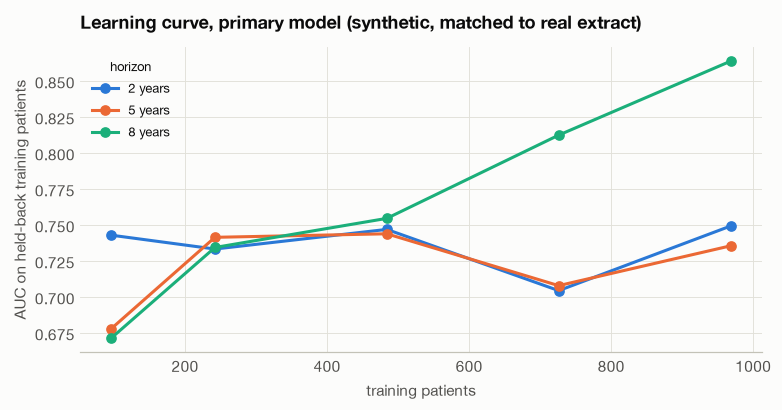

,share,patients,events,AUC 2y,AUC 5y,AUC 8y
0,0.10,96,65,0.743,0.678,0.671
1,0.25,242,207,0.733,0.741,0.734
2,0.50,484,281,0.747,0.744,0.755
3,0.75,726,512,0.704,0.708,0.812
4,1.00,969,696,0.749,0.736,0.864


In [7]:
rng = np.random.default_rng(0)
patients = meta.patient_id[train].unique()
val_patients = set(rng.choice(patients, len(patients) // 4, replace=False))
is_val = meta.patient_id.isin(val_patients).to_numpy() & train
pool = [p for p in patients if p not in val_patients]
curve = []
for share in [0.1, 0.25, 0.5, 0.75, 1.0]:
    pick = set(rng.choice(pool, int(len(pool) * share), replace=False))
    fit_rows = meta.patient_id.isin(pick).to_numpy() & train
    m = ml.DiscreteTimeCompetingRisks(FEATURES, kind="gbm", horizon=H, **best).fit(X[fit_rows], meta[fit_rows])
    p = m.predict_cif(X[is_val])
    curve.append(dict(share=share, patients=len(pick), events=m.n_events_["svd"],
                      **{f"AUC {h}y": ml.cr_auc(p[f"svd_{h}y"], meta.time_to_end[is_val], meta.status[is_val], h) for h in HORIZONS}))
curve = pd.DataFrame(curve)
fig, ax = plt.subplots(figsize=(8, 3.6))
for i, h in enumerate(HORIZONS):
    ax.plot(curve.patients, curve[f"AUC {h}y"], marker="o", markersize=6, color=viz.SERIES[i], label=f"{h} years")
ax.set_xlabel("training patients")
ax.set_ylabel("AUC on held-back training patients")
ax.legend(title="horizon", fontsize=8.5, title_fontsize=8.5)
ax.set_title(f"Learning curve, primary model ({LABEL})")
viz.save(fig, "04_learning_curve")
plt.show()
curve.round(3)

## 4. First check on the test valves

Competing-risk time-dependent AUC and Brier score (inverse probability of censoring weights; cases have SVD by the horizon, controls are event-free at the horizon or died first) on valves implanted after the split year, next to the mean predicted risk and the observed cumulative incidence. Calibration curves, decision curves and the ladder are in the evaluation step.

In [8]:
models = {"calendar schedule": calendar, "valve age only": time_only, "Cox, risk factors": cox, "regression baseline": baseline,
          "gradient boosting": primary, "gradient boosting, no constraints": unconstrained}
G = ml.censoring_survival(meta.time_to_end[test], meta.status[test])
predictions, rows = {}, {}
for name, model in models.items():
    cif = model.predict_cif(X[test])
    predictions[name] = cif
    for h in HORIZONS:
        p = cif[f"svd_{h}y"]
        rows[(name, h)] = {"AUC": ml.cr_auc(p, meta.time_to_end[test], meta.status[test], h, G),
                           "Brier": ml.cr_brier(p, meta.time_to_end[test], meta.status[test], h, G),
                           "mean predicted": p.mean()}
observed = {h: ml.aalen_johansen(meta.time_to_end[test], meta.status[test], h) for h in HORIZONS}
perf = pd.DataFrame(rows).T.rename_axis(["model", "horizon"])
table = perf.unstack("horizon")
display(table.style.format("{:.3f}").format("{:.1%}", subset=[c for c in table.columns if c[0] == "mean predicted"]))
pd.Series({f"{h} years": f"{v:.1%}" for h, v in observed.items()}, name=f"observed SVD, Aalen-Johansen ({LABEL}, test valves)").to_frame()

,"observed SVD, Aalen-Johansen (synthetic, matched to real extract, test valves)"
2 years,7.3%
5 years,24.4%
8 years,49.6%


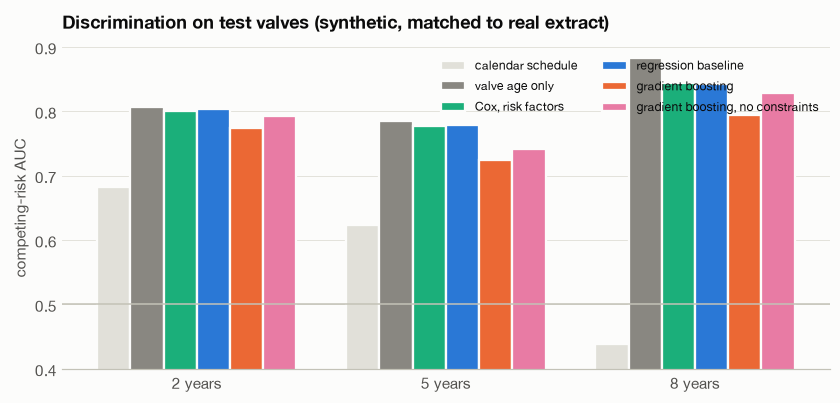

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
names = list(models)
x = np.arange(len(HORIZONS))
width = 0.8 / len(names)
palette = [viz.GRID, viz.MUTED, viz.SERIES[2], viz.SERIES[0], viz.SERIES[1], "#e87ba4"]
for i, name in enumerate(names):
    vals = [perf.loc[(name, h), "AUC"] for h in HORIZONS]
    ax.bar(x + (i - (len(names) - 1) / 2) * width, vals, width=width, color=palette[i], edgecolor=viz.SURFACE, linewidth=1.5, label=name)
ax.axhline(0.5, color=viz.AXIS, linewidth=1)
ax.set_xticks(x, [f"{h} years" for h in HORIZONS])
ax.set_ylim(0.4, 0.9)
ax.set_ylabel("competing-risk AUC")
ax.grid(axis="x", visible=False)
ax.legend(fontsize=8, ncol=2, loc="upper right")
ax.set_title(f"Discrimination on test valves ({LABEL})")
viz.save(fig, "04_auc_by_model")
plt.show()

**What the test valves show (synthetic cohort matched to the real extract).**

- Once the training data look like the extract, valve age carries most of the signal: the valve-age-only model ranks as well as any other (AUC 0.81, 0.78 and 0.88 at 2, 5 and 8 years), level with the regression baseline (0.80, 0.78, 0.84) and the Cox comparator (0.80, 0.78, 0.84). The constrained boosted model is lower (0.78, 0.72, 0.79), because age, EOA and most echo values are missing at the extract's rates and every event is a reintervention.
- Observed incidence is high (24 percent at 5 years) because event-free valves are followed as briefly as in the extract while failing valves keep their follow-up. That reproduces how the extract was assembled, and it is why every model predicts far more SVD on the real valves than they show.

## 5. What drives the primary model

SHAP values for the yearly SVD hazard of the primary model, on test rows in the first year after the landmark. Positive values raise the predicted hazard.

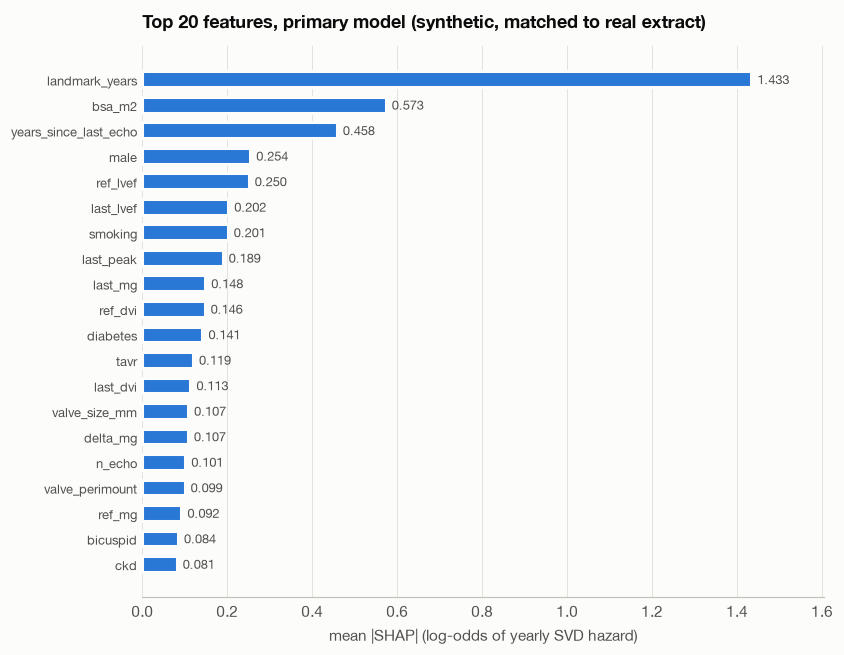

,mean |SHAP|,value vs SHAP correlation,expected direction
landmark_years,1.433,0.979,1
bsa_m2,0.573,0.417,0
years_since_last_echo,0.458,0.575,0
male,0.254,0.428,0
ref_lvef,0.250,-0.335,0
last_lvef,0.202,-0.039,0
smoking,0.201,0.941,1
last_peak,0.189,0.674,1
last_mg,0.148,0.763,1
ref_dvi,0.146,-0.859,-1


In [10]:
import shap
sample = X[test].sample(min(1500, int(test.sum())), random_state=0)
design = primary._design(sample[FEATURES].reset_index(drop=True).assign(interval=1))
explainer = shap.TreeExplainer(primary.svd_)
values = explainer.shap_values(design)
importance = pd.Series(np.abs(values).mean(axis=0), index=design.columns).drop("interval").sort_values(ascending=False)
top = importance.head(20)
fig, ax = plt.subplots(figsize=(8, 6.5))
viz.hbar(ax, list(top.index), list(top.values), value_fmt="{:.3f}", xlabel="mean |SHAP| (log-odds of yearly SVD hazard)")
ax.tick_params(axis="y", labelsize=8.5)
ax.set_title(f"Top 20 features, primary model ({LABEL})")
viz.save(fig, "04_shap_importance")
plt.show()
agree = {}
for f in top.index:
    col = list(design.columns).index(f)
    ok = design[f].notna().to_numpy()
    agree[f] = np.corrcoef(design[f][ok], values[ok, col])[0, 1] if design[f][ok].nunique() > 1 else np.nan
pd.DataFrame({"mean |SHAP|": top, "value vs SHAP correlation": pd.Series(agree), "expected direction": [ml.FEATURES[f]["direction"] for f in top.index]}).round(3)

### One prediction, as a clinician would see it

A test valve at a follow-up visit: its predicted SVD risk at each horizon, the risk tier, the echo interval that tier maps to, and the three features that moved its risk most.

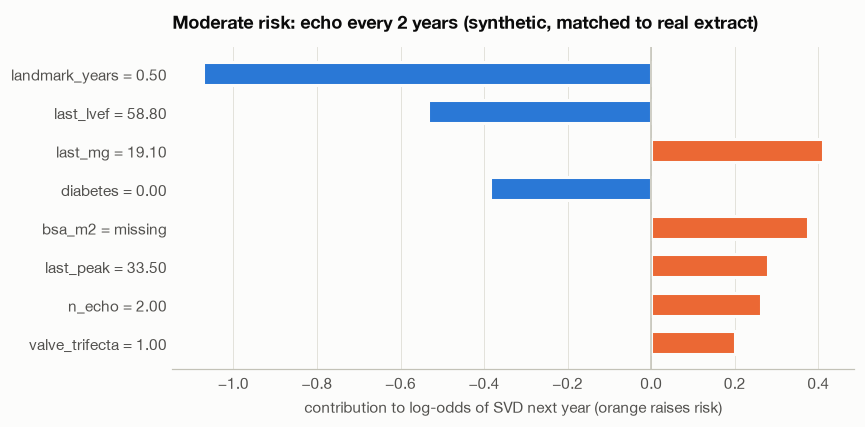

,prediction
SVD within 2 years,0.6%
SVD within 5 years,15.0%
SVD within 8 years,46.3%
risk tier (5-year risk),moderate
recommended echo interval,echo every 2 years
main reasons,landmark years lowers risk; last lvef lowers r...
valve age at this visit,0.5 years


In [11]:
cif_test = predictions["gradient boosting"]
row = cif_test["svd_5y"].sub(0.15).abs().idxmin()
one = X.loc[[row], FEATURES]
d1 = primary._design(one.reset_index(drop=True).assign(interval=1))
contrib = pd.Series(explainer.shap_values(d1)[0], index=d1.columns).drop("interval")
top8 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(8)
tier, action = ml.risk_tier(cif_test.loc[row, "svd_5y"])
fig, ax = plt.subplots(figsize=(8, 3.8))
labels = [f"{f} = {one.iloc[0][f]:.2f}" if pd.notna(one.iloc[0][f]) else f"{f} = missing" for f in top8.index]
ax.barh(labels, top8.values, color=[viz.SERIES[1] if v > 0 else viz.SERIES[0] for v in top8.values], height=0.6, edgecolor=viz.SURFACE, linewidth=2)
ax.axvline(0, color=viz.AXIS, linewidth=1)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set_xlabel("contribution to log-odds of SVD next year (orange raises risk)")
ax.set_title(f"{tier.capitalize()} risk: {action} ({LABEL})")
viz.save(fig, "04_single_prediction")
plt.show()
words = [f"{f.replace('_', ' ')} {'raises' if v > 0 else 'lowers'} risk" for f, v in top8.head(3).items()]
pd.Series({**{f"SVD within {h} years": f"{cif_test.loc[row, f'svd_{h}y']:.1%}" for h in HORIZONS}, "risk tier (5-year risk)": tier,
           "recommended echo interval": action, "main reasons": "; ".join(words), "valve age at this visit": f"{meta.loc[row, 'landmark_years']:g} years"}, name="prediction").to_frame()

In [12]:
tiers = cif_test["svd_5y"].map(lambda p: ml.risk_tier(p)[0])
by_tier = pd.DataFrame({"test rows": tiers.value_counts(), "mean 5-year risk": cif_test["svd_5y"].groupby(tiers).mean().map("{:.1%}".format)}).reindex([t[1] for t in ml.RISK_TIERS])
by_tier["threshold"] = ["under 5%", "5 to 15%", "15% or more"]
by_tier["action"] = [t[2] for t in ml.RISK_TIERS]
by_tier

,test rows,mean 5-year risk,threshold,action
svd_5y,,,,
low,1015,1.8%,under 5%,guideline schedule
moderate,639,9.0%,5 to 15%,echo every 2 years
high,1802,66.5%,15% or more,echo every year


## 6. The trained models on the real extract

The real extract, prepared by `02_preprocessing.ipynb` and converted by `landmarks.from_preprocessing`, run through the same landmark and feature code and scored by the models trained above. Nothing is refitted: every real landmark row is test data.

What to expect before looking at the numbers: one row per valve, dates to the year, age missing for everyone, echo values for a minority of rows, no deaths recorded (so the competing risk never fires), and only structural events that the provisional rule accepted, all of them reinterventions. Few events means wide uncertainty, so a patient-level bootstrap interval is shown for the 5-year AUC. Only counts and metrics are printed.

In [13]:
REAL = ROOT / "data" / "processed"
real_available = (REAL / "implants.parquet").exists()
if not real_available:
    print("Real extract not prepared on this machine: run 02_preprocessing.ipynb first. Section skipped.")
else:
    from pipeline import landmarks
    importlib.reload(landmarks)
    real_tables = landmarks.from_preprocessing(REAL)
    real_lm, real_outcomes = landmarks.build_landmark_table(real_tables, bundle["labels"])
    Xr, mr = ml.feature_matrix(real_lm)
    Xr = Xr.reindex(columns=X.columns)
    display(pd.Series({
        "valves with a known implant year": len(real_outcomes),
        "valves with a structural event": int(real_outcomes.status.eq("svd").sum()),
        "valves scored (followed beyond 6 months)": mr.patient_id.nunique(),
        "landmark rows": len(mr),
        "valves with an event among those scored": mr.patient_id[mr.status.eq("svd")].nunique(),
        "deaths recorded": int(real_outcomes.status.eq("death").sum()),
    }, name="real extract").to_frame())
    availability = Xr.notna().mean()
    display(availability[availability > 0].sort_values(ascending=False).map("{:.0%}".format).rename("share of real rows with a value").to_frame().T)

,real extract
valves with a known implant year,117
valves with a structural event,8
valves scored (followed beyond 6 months),51
landmark rows,301
valves with an event among those scored,8
deaths recorded,0


,landmark_years,n_echo,tavr,male,valve_sapien_3,valve_evolut,valve_trifecta,valve_perimount,valve_epic,valve_magna,...,max_mg,last_peak,ref_ar,delta_mg,delta_ar,ref_mg,last_lvef,ref_peak,ref_lvef,last_dvi
share of real rows with a value,100%,100%,100%,98%,95%,95%,95%,95%,95%,95%,...,14%,10%,8%,8%,8%,8%,6%,5%,4%,2%


In [14]:
if real_available:
    Gr = ml.censoring_survival(mr.time_to_end, mr.status)
    real_rows, real_pred = {}, {}
    for name, model in models.items():
        cif = model.predict_cif(Xr)
        real_pred[name] = cif
        for h in HORIZONS:
            p = cif[f"svd_{h}y"]
            real_rows[(name, h)] = {"AUC": ml.cr_auc(p, mr.time_to_end, mr.status, h, Gr), "Brier": ml.cr_brier(p, mr.time_to_end, mr.status, h, Gr), "mean predicted": p.mean()}
    real_perf = pd.DataFrame(real_rows).T.rename_axis(["model", "horizon"]).unstack("horizon")
    display(real_perf.style.format("{:.3f}").format("{:.1%}", subset=[c for c in real_perf.columns if c[0] == "mean predicted"]))
    display(pd.Series({f"{h} years": f"{ml.aalen_johansen(mr.time_to_end, mr.status, h):.1%}" for h in HORIZONS}, name="observed, Aalen-Johansen (real extract, no deaths recorded)").to_frame())
    rng = np.random.default_rng(0)
    pats = mr.patient_id.unique()
    boot = {n: [] for n in models}
    for _ in range(300):
        idx = np.concatenate([np.flatnonzero(mr.patient_id.to_numpy() == p) for p in rng.choice(pats, len(pats), replace=True)])
        for n in models:
            boot[n].append(ml.cr_auc(real_pred[n]["svd_5y"].to_numpy()[idx], mr.time_to_end.iloc[idx], mr.status.iloc[idx], 5))
    ci = pd.DataFrame({n: {"5-year AUC": real_rows[(n, 5)]["AUC"], "95% interval": "{:.2f} to {:.2f}".format(*np.nanpercentile(v, [2.5, 97.5]))} for n, v in boot.items()}).T
    display(ci.style.format({"5-year AUC": "{:.2f}"}))

,"observed, Aalen-Johansen (real extract, no deaths recorded)"
2 years,3.8%
5 years,12.6%
8 years,29.0%


,5-year AUC,95% interval
calendar schedule,0.67,0.49 to 0.83
valve age only,0.74,0.50 to 0.94
"Cox, risk factors",0.75,0.50 to 0.94
regression baseline,0.78,0.60 to 0.95
gradient boosting,0.57,0.30 to 0.82
"gradient boosting, no constraints",0.71,0.58 to 0.86


**Reading the real-extract result.** The models were trained where age and serial dated echoes exist. On the extract those inputs are mostly empty, so each model leans on whatever is left, usually valve age. With a handful of events, the bootstrap intervals are wide enough to overlap chance for most models. This is the protocol's argument in numbers: the method needs age at implant and dated serial echoes, which the extract does not supply, and not a different model.

**Real extract, after training on matched data.** Trained on the ideal cohort, the boosted model had ranked the real valves worse than chance (5-year AUC 0.29). Trained on the matched cohort, the regression baseline does best (0.78, 95% interval 0.60 to 0.95), followed by the Cox comparator (0.75) and valve age alone (0.74); the unconstrained boosted model reaches 0.71 and the constrained one 0.57 (0.30 to 0.82). With 8 events the intervals overlap, so no ranking between models is established. Predicted 5-year risk (39 to 53 percent) is far above the observed 12.6 percent: the matched follow-up carries the extract's selection bias into training, so the models need recalibration on real outcomes before any clinical use. Next levers: switch feature selection on to drop fields that are empty in the extract, and match event-free follow-up without keeping the full follow-up of failing valves.

## 6. Save

In [15]:
for name, model in {"calendar": calendar, "time_only": time_only, "cox": cox, "baseline": baseline, "primary": primary, "primary_unconstrained": unconstrained}.items():
    (MODELS / f"{name}.pkl").write_bytes(pickle.dumps(model))
pickle.dump(dict(predictions=predictions, performance=perf, observed=observed, best_params=best, label=LABEL, real_performance=real_perf if real_available else None), open(MODELS / "training_results.pkl", "wb"))
sorted(p.name for p in MODELS.glob("*.pkl"))

['baseline.pkl',
 'calendar.pkl',
 'cox.pkl',
 'primary.pkl',
 'primary_unconstrained.pkl',
 'time_only.pkl',
 'training_results.pkl']